### Credit Card Fraud Detection using Machine Learning

**1. Import Required Libraries**

In [91]:
#Import all the libraries required for data manipulation, visualization, and machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

**2. Load the Dataset**

In [3]:
#Load the dataset and display first 5 rows

df = pd.read_csv("/content/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**3. Dataset Overview**

In [4]:
#See shape of the data

df.shape

(284807, 31)

In [5]:
#See what all columns are present

df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [6]:
#Get info about various columns in the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
#Get an overview of data including count, mean, min, max etc

df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**4. Data Cleaning**

In [8]:
#Check for NULL values

df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [9]:
#Check for duplicate rows

duplicate_rows = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 1081


In [10]:
#Drop duplicate rows

df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (283726, 31)


**5. Exploratory Data Analysis (EDA)**

In [11]:
#See the distribution of fraud and genuine class (0 -> Genuine & 1 -> Fraud)

df["Class"].value_counts()

,count
Class,
0,283253
1,473


In [12]:
#Calculate fraud percentage after dropping duplicates

fraud_percentage = (df["Class"].sum() / len(df)) * 100

print(fraud_percentage)

0.1667101358352777


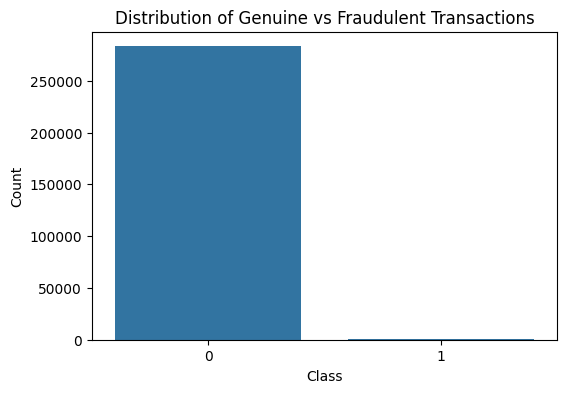

In [13]:
#Visualizing the distribution of Class (Genuine vs Fraud):

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Class")
plt.title("Distribution of Genuine vs Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

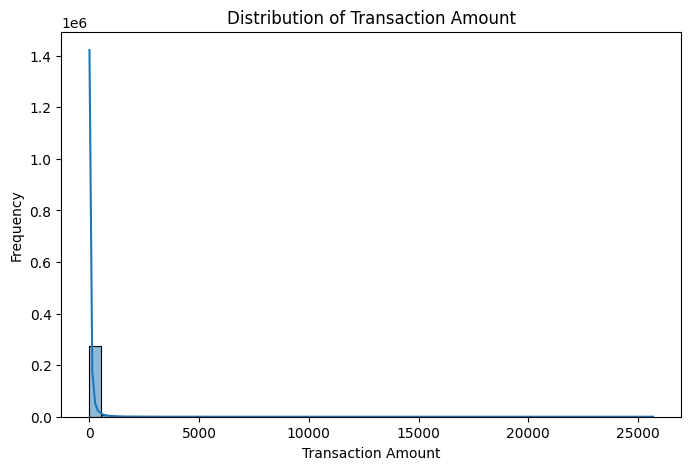

In [14]:
# Visualize the distribution of transaction amounts

plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50, kde = True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

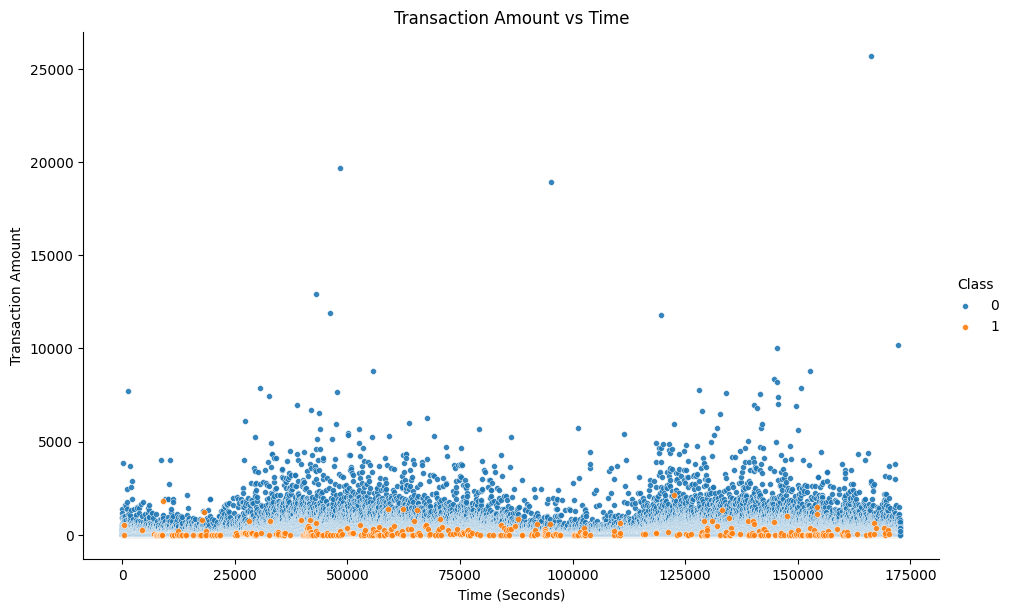

In [15]:
#Visualizing Transaction Amount and Time for Fraud and Genuine

g = sns.FacetGrid(
    df,
    hue="Class",
    height=6,
    aspect=1.6
)

g.map_dataframe(
    sns.scatterplot,
    x="Time",
    y="Amount",
    alpha=0.9,
    s=18
)

g.add_legend()

plt.title("Transaction Amount vs Time")
plt.xlabel("Time (Seconds)")
plt.ylabel("Transaction Amount")

plt.show()

**6. Data Pre-Processing**

In [16]:
# Separate Features and Target Variable

X = df.drop("Class", axis=1)
y = df["Class"]

In [17]:
# Check the shape of features and target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (283726, 30)
Shape of y: (283726,)


In [18]:
# Split the data into Training and Testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
# Check the shape of training and testing sets

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (226980, 30)
X_test shape: (56746, 30)
y_train shape: (226980,)
y_test shape: (56746,)


In [21]:
#Feature Scaling --> Create a StandardScaler object

scaler = StandardScaler()

In [22]:
# Scale the Time and Amount columns

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

**7. Logistic Regression**

In [23]:
# Creating Logistic Regression model

log_model = LogisticRegression(random_state=42)

In [24]:
# Train the Logistic Regression model

log_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [25]:
# Predict on test data

y_pred = log_model.predict(X_test)

In [26]:
# Logistic Regression Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9991365030134283
Precision: 0.8484848484848485
Recall   : 0.5894736842105263
F1 Score : 0.6956521739130435


In [27]:
# Logistic Regression Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [28]:
# Logistic Regression Confusion Matrix

cm_lr = confusion_matrix(y_test, y_pred)
print(cm_lr)

[[56641    10]
 [   39    56]]


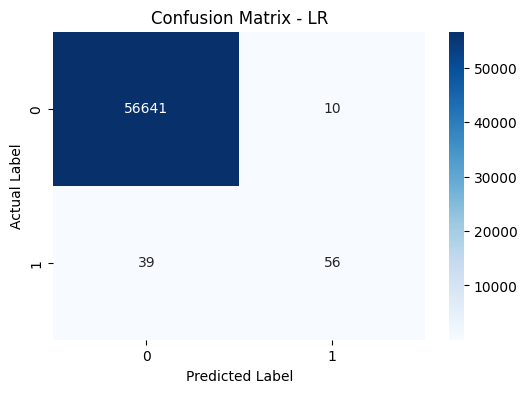

In [30]:
# Visualizing Confusion Matrix - Logistic Regression

plt.figure(figsize=(6,4))

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - LR")

plt.show()

**8. Handling Class Imbalance with SMOTE + Logistic Regression**

In [31]:
# Creating SMOTE Object

smote = SMOTE(random_state=42)

In [32]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [33]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [34]:
# Train SMOTE + Logistic Regression Model

log_model_smote = LogisticRegression(random_state=42)

log_model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(random_state=42)

In [35]:
# Predict on test data

y_pred_smote = log_model_smote.predict(X_test)

In [36]:
# SMOTE + Logistic Regression Evaluation

accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print("Accuracy :", accuracy_smote)
print("Precision:", precision_smote)
print("Recall   :", recall_smote)
print("F1 Score :", f1_smote)

Accuracy : 0.9736721531033025
Precision: 0.053035143769968054
Recall   : 0.8736842105263158
F1 Score : 0.1


In [37]:
# SMOTE + Logistic Regression Classification Report

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [38]:
# SMOTE + Logistic Regression Confusion Matrix

cm_smote = confusion_matrix(y_test, y_pred_smote)
print(cm_smote)

[[55169  1482]
 [   12    83]]


In [ ]:
#Visualizing Confusion Matrix - SMOTE + Logistic Regression

plt.figure(figsize=(6,4))

sns.heatmap(cm_smote, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - SMOTE + LR")

plt.show()

**9. Decision Tree**

In [39]:
# Creating Decision Tree model

dt_model = DecisionTreeClassifier(random_state=42)

In [40]:
# Train Decision Tree Model

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [42]:
# Predict on test data

y_pred_dt = dt_model.predict(X_test)

In [43]:
# Decision Tree Evaluation

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1 Score :", f1_dt)

Accuracy : 0.999048391076023
Precision: 0.7204301075268817
Recall   : 0.7052631578947368
F1 Score : 0.7127659574468085


In [44]:
# Decision Tree Classification Report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.71      0.71        95

    accuracy                           1.00     56746
   macro avg       0.86      0.85      0.86     56746
weighted avg       1.00      1.00      1.00     56746



In [45]:
# Decision Tree Confusion Matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[56625    26]
 [   28    67]]


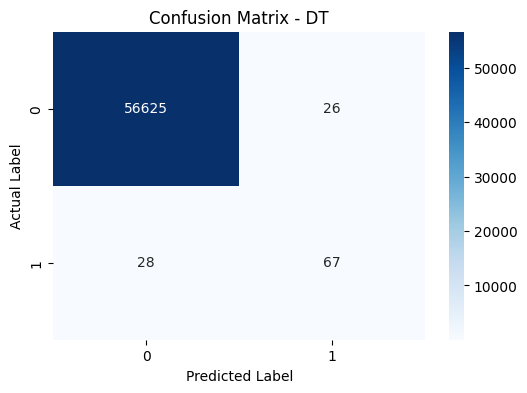

In [46]:
#Visualizing Confusion Matrix - Decision Tree

plt.figure(figsize=(6,4))

sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - DT")

plt.show()

**10. Random Forest**

In [49]:
# Creating Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [50]:
# Train Random Forest Model

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [51]:
# Predict on test data

y_pred_rf = rf_model.predict(X_test)

In [52]:
# Random Forest Evaluation

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Accuracy : 0.9995065731505305
Precision: 0.971830985915493
Recall   : 0.7263157894736842
F1 Score : 0.8313253012048193


In [53]:
# Random Forest Classification Report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [54]:
# Random Forest Confusion Matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[56649     2]
 [   26    69]]


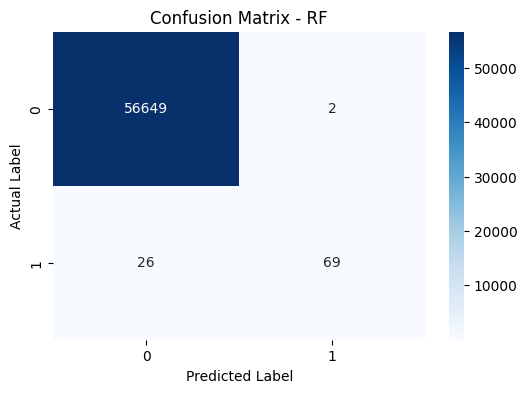

In [55]:
#Visualizing Confusion Matrix - Random Forest

plt.figure(figsize=(6,4))

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - RF")

plt.show()

**11. XGBoost - Not Tuned**

In [56]:
#Creating XG Boost Model

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

In [58]:
#Train XGBoost-1 Model

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [59]:
# Predict on test data

y_pred_xgb = xgb_model.predict(X_test)

In [60]:
# XGBoost-1 Evaluation

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("Accuracy :", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)

Accuracy : 0.9994713283755683
Precision: 0.9452054794520548
Recall   : 0.7263157894736842
F1 Score : 0.8214285714285714


In [61]:
# XGBoost-1 Classification Report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.73      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [62]:
# XGBoost-1 Confusion Matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

[[56647     4]
 [   26    69]]


Text(0.5, 1.0, 'Confusion Matrix - XGB')

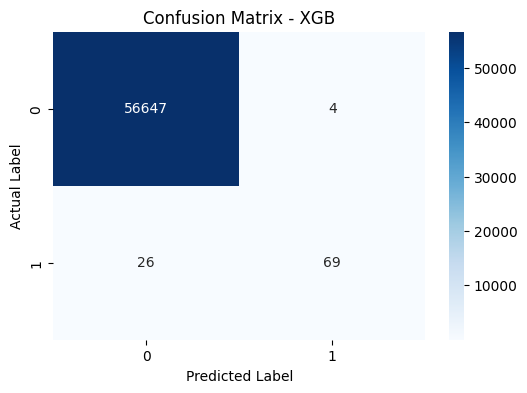

In [63]:
#Visualizing Confusion Matrix - XGBoost 1

plt.figure(figsize=(6,4))

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XGB")

**12. Hyperparameter Tuning using GridSearchCV**

In [64]:
#Creating a parameter grid

param_grid = {
    "n_estimators": [100, 120],
    "max_depth": [5, 6],
    "learning_rate": [0.055, 0.1]
}

In [66]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

In [67]:
#Train GridSearch

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.055, 0.1], 'max_depth': [5, 6],
                         'n_estimators': [100, 120]},
             scoring='f1')

In [68]:
#Getting Best Parameters

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.055, 'max_depth': 6, 'n_estimators': 120}


**13. XGBoost - Tuned using GridSearchCV Parameters**

In [69]:
#Creating XG Boost Model - Tuned

xgb_model2 = XGBClassifier(
    n_estimators=120,
    max_depth=6,
    learning_rate=0.055,
    random_state=42,
    eval_metric="logloss"
)

In [70]:
#Train XGBoost-2 Model

xgb_model2.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.055, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=120, n_jobs=None,
              num_parallel_tree=None, ...)

In [71]:
# Predict on test data

y_pred_xgb2 = xgb_model2.predict(X_test)

In [72]:
# XGBoost-2 Evaluation

accuracy_xgb2 = accuracy_score(y_test, y_pred_xgb2)
precision_xgb2 = precision_score(y_test, y_pred_xgb2)
recall_xgb2 = recall_score(y_test, y_pred_xgb2)
f1_xgb2 = f1_score(y_test, y_pred_xgb2)

print("Accuracy :", accuracy_xgb2)
print("Precision:", precision_xgb2)
print("Recall   :", recall_xgb2)
print("F1 Score :", f1_xgb2)

Accuracy : 0.9995418179254926
Precision: 0.96
Recall   : 0.7578947368421053
F1 Score : 0.8470588235294118


In [73]:
# XGBoost-2 Classification Report

print(classification_report(y_test, y_pred_xgb2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.76      0.85        95

    accuracy                           1.00     56746
   macro avg       0.98      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746



In [74]:
# XGBoost-2 Confusion Matrix

cm_xgb2 = confusion_matrix(y_test, y_pred_xgb2)
print(cm_xgb2)

[[56648     3]
 [   23    72]]


Text(0.5, 1.0, 'Confusion Matrix - XGB-2')

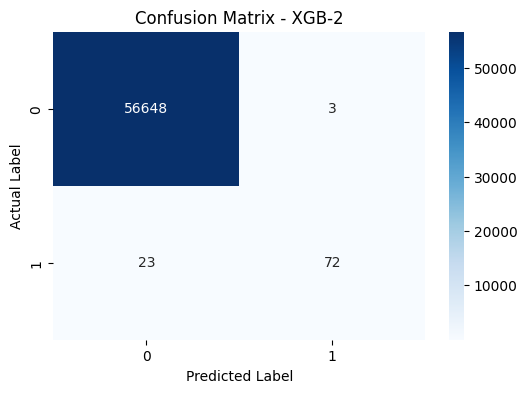

In [75]:
#Visualizing Confusion Matrix - XGBoost-2

plt.figure(figsize=(6,4))

sns.heatmap(cm_xgb2, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - XGB-2")

**14. Model Comparison**

**Metrics Performance Comparison**

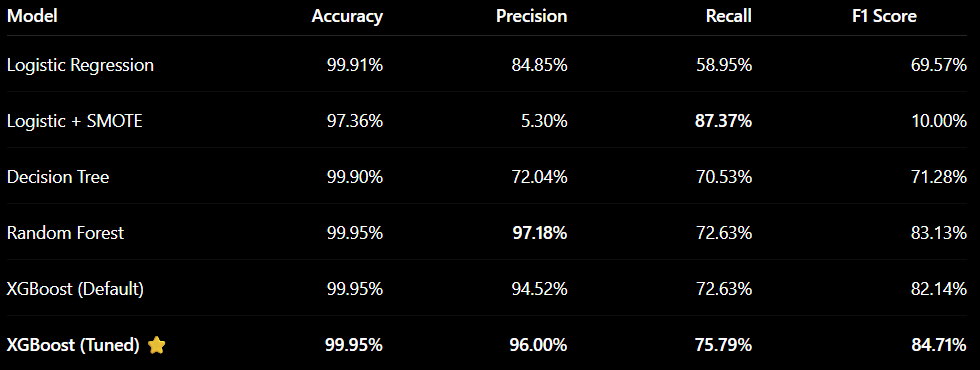

**ROC Curve Comparison**

In [76]:
# Probability Predictions --> Combined for all the models

y_prob_lr = log_model.predict_proba(X_test)[:,1]

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

y_prob_xgb2 = xgb_model2.predict_proba(X_test)[:,1]

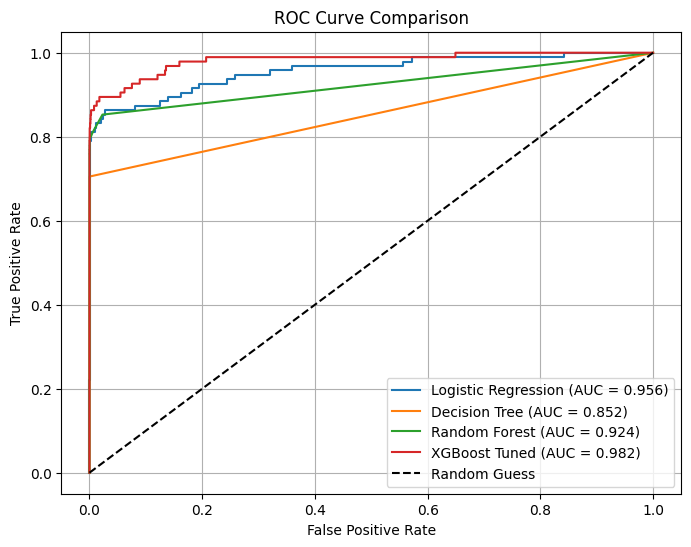

In [77]:
#Combined Plotting of ROC-AUC Curve

plt.figure(figsize=(8,6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr, tpr,
         label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")

# Decision Tree
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr, tpr,
         label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})")

# Random Forest
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr,
         label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")

# XGBoost Tuned
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb2)
plt.plot(fpr, tpr,
         label=f"XGBoost Tuned (AUC = {roc_auc_score(y_test, y_prob_xgb2):.3f})")

# Random Classifier
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.grid(True)

plt.show()

**Precision-Recall Curve Comparison**

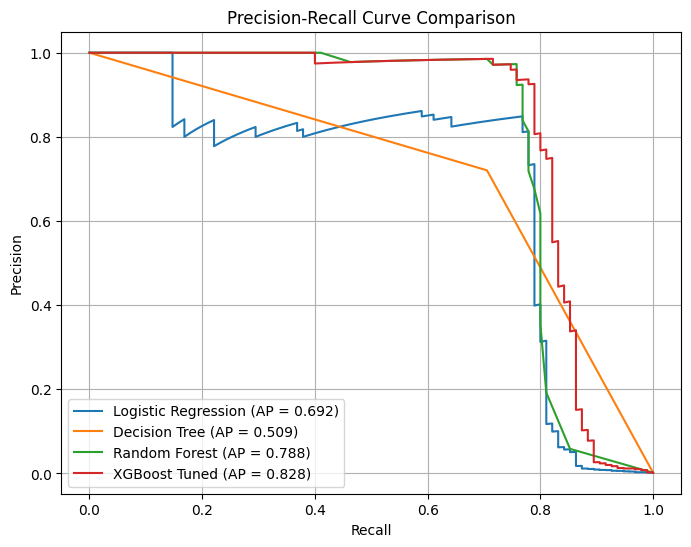

In [78]:
#Combined Precision Recall Curve

plt.figure(figsize=(8,6))

# Logistic Regression
precision, recall, _ = precision_recall_curve(y_test, y_prob_lr)
ap = average_precision_score(y_test, y_prob_lr)
plt.plot(recall, precision,
         label=f"Logistic Regression (AP = {ap:.3f})")

# Decision Tree
precision, recall, _ = precision_recall_curve(y_test, y_prob_dt)
ap = average_precision_score(y_test, y_prob_dt)
plt.plot(recall, precision,
         label=f"Decision Tree (AP = {ap:.3f})")

# Random Forest
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf)
ap = average_precision_score(y_test, y_prob_rf)
plt.plot(recall, precision,
         label=f"Random Forest (AP = {ap:.3f})")

# XGBoost Tuned
precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb2)
ap = average_precision_score(y_test, y_prob_xgb2)
plt.plot(recall, precision,
         label=f"XGBoost Tuned (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()

plt.grid(True)

plt.show()

**15. Feature Importance - Random Forest & XGBoost**

**For Random Forest**

In [84]:
#Create a Feature Importance Object - Random Forest

feature_importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

In [92]:
#Sort the features because of how frequently they are used by the model

feature_importance_rf = feature_importance_rf.sort_values(ascending=False)

In [93]:
#Find Top 10 features - Random Forest

print(feature_importance_rf.head(10))

V17    0.156591
V14    0.135281
V12    0.130206
V10    0.087799
V16    0.072675
V11    0.050980
V9     0.033680
V18    0.031980
V4     0.025802
V7     0.024569
dtype: float64


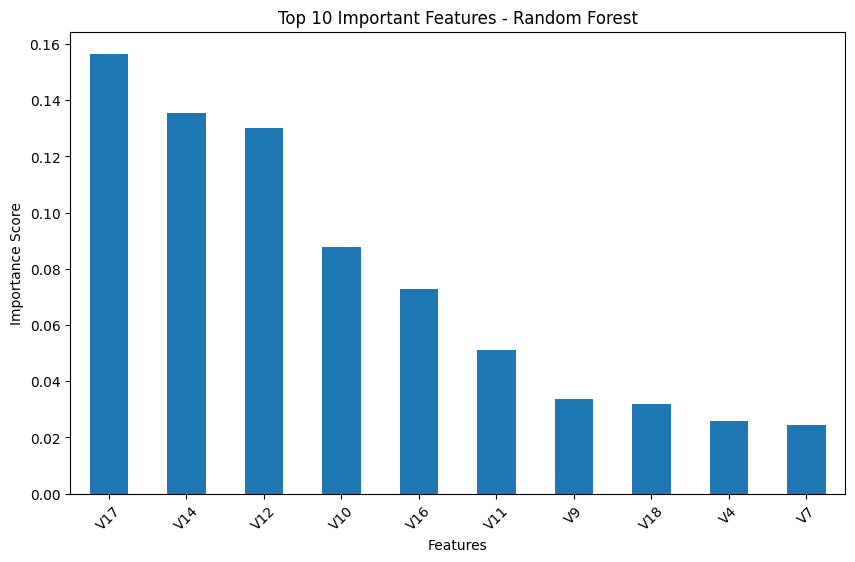

In [94]:
#Visualize top 10 features for Random Forest

plt.figure(figsize=(10,6))

feature_importance_rf.head(10).plot(kind="bar")

plt.title("Top 10 Important Features - Random Forest")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

**For XGBoost**

In [87]:
#Create a Feature Importance Object - XGBoost

feature_importance_xgb = pd.Series(
    xgb_model2.feature_importances_,
    index=X.columns
)

In [88]:
#Sort the features because of how frequently they are used by the model

feature_importance_xgb = feature_importance_xgb.sort_values(ascending=False)

In [89]:
#Find Top 10 features - XGBoost

print(feature_importance_xgb.head(10))

V14    0.564831
V12    0.076126
V10    0.046820
V4     0.026024
V17    0.018347
V27    0.016548
V28    0.014606
V26    0.014304
V5     0.014064
V7     0.013135
dtype: float32


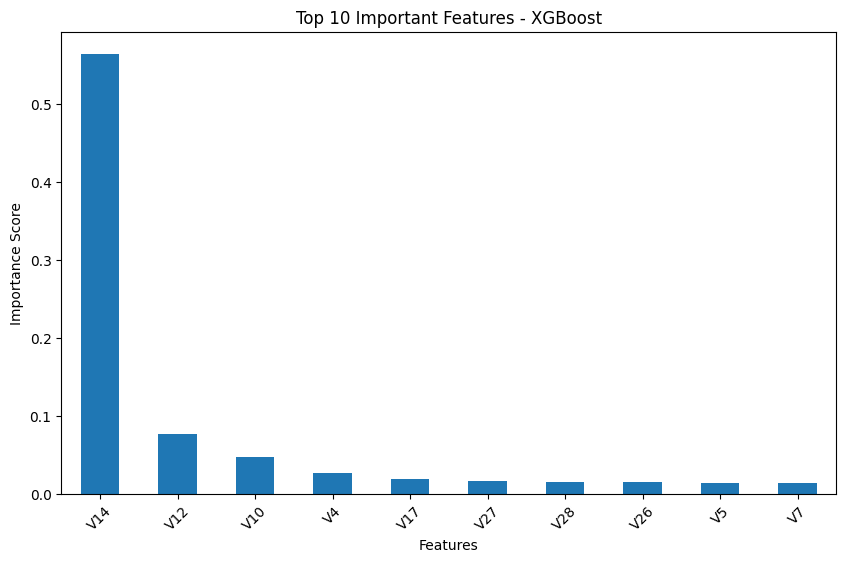

In [90]:
#Visualize top 10 features for XGBoost

plt.figure(figsize=(10,6))

feature_importance_xgb.head(10).plot(kind="bar")

plt.title("Top 10 Important Features - XGBoost")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

**16. Conclusion**

*   XGBoost (Tuned) achieved the best overall performance
*   Recall, Precision and F1 Score were more informative due to severe class imbalance
*   Feature Importance showed that PCA components V14, V12 and V17 contributed most towards fraud detection

